In [3]:
# Initialize Otter
import otter
grader = otter.Notebook("check_dijkstra.ipynb")

# Instructions

This assignment implements Dijkstra's shortest path on a graph, finding an unvisited node in a graph, picking which one to visit, and taking a path in the map and generating waypoints along that path

Given to you:
- Priority queue
- Image handling
- Four and eight connected neighbors

Slides: https://docs.google.com/presentation/d/1XBPw2B2Bac-LcXH5kYN4hQLLLl_AMIgoowlrmPpTinA/edit?usp=sharing


In [4]:
# The ever-present numpy
import numpy as np

# Our priority queue
import heapq

# Using imageio to read in the image
import imageio

# Operating system commands
import os


In [5]:
# These commands will force JN to actually re-load the external file when you re-execute the import command
%load_ext autoreload
%autoreload 2

# Run Dijkstra on a pretend SLAM map



In [6]:
if os.path.exists("path_planning.py"):
    from path_planning import dijkstra, plot_with_path, open_image, check_path_continuous
else:
    cur_dir = os.getcwd()
    if "Assignments" in cur_dir or "Skills" in cur_dir:
        path_planning_dir = "../ros_ws/src/lab3/lab3"

        os.chdir(path_planning_dir)
        from path_planning import dijkstra, plot_with_path, open_image, check_path_continuous
        os.chdir(cur_dir)

/home/elliot/Desktop/CodingProjects/ROB456/Assignments
Goal (60, 80) not reached, taking closest


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


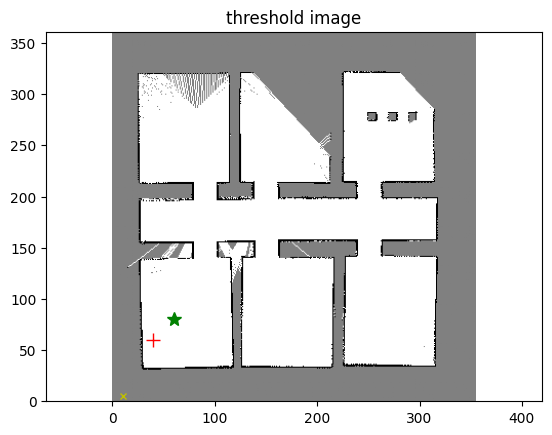

In [7]:
# Opens and threshold the SLAM map image
_, im_thresh = open_image("map.pgm")

# GUIDE:
#.  Try the different start/goal locations. 
robot_start_loc = (40, 60)
# Closer one to try - change this after it works...
robot_goal_loc_close = (60, 80)
robot_goal_hallway = (80, 175)
robot_goal_next_room = (130, 50)
zoom = 1.0

robot_goal_loc = robot_goal_loc_close
path = dijkstra(im_thresh, robot_start_loc, robot_goal_loc)
plot_with_path(im_thresh, zoom=zoom, robot_loc=robot_start_loc, goal_loc=robot_goal_loc, path=path)

# NOTE: The path is correct if it is connected, doesn't loop back on itself, gets to the goal, and is "snapped" to the edges


In [8]:
grader.check("dijkstra")

dijkstra results:
    dijkstra - 1 result:
        ❌ Test case failed
        Trying:
            path_straight = dijkstra(im_thresh, robot_loc=(40, 60), goal_loc=(60, 80))
        Expecting nothing
        **********************************************************************
        Line 1, in dijkstra 0
        Failed example:
            path_straight = dijkstra(im_thresh, robot_loc=(40, 60), goal_loc=(60, 80))
        Expected nothing
        Got:
            Goal (60, 80) not reached, taking closest
        Trying:
            assert check_path_continuous(im_thresh, path_straight, 41, 21)
        Expecting nothing
        **********************************************************************
        Line 2, in dijkstra 0
        Failed example:
            assert check_path_continuous(im_thresh, path_straight, 41, 21)
        Exception raised:
            Traceback (most recent call last):
              File "/usr/lib/python3.12/doctest.py", line 1361, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest dijkstra 0[1]>", line 1, in <module>
                assert check_path_continuous(im_thresh, path_straight, 41, 21)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
            AssertionError

    dijkstra - 2 result:
        ❌ Test case failed
        Trying:
            path_one_bend = dijkstra(im_thresh, robot_loc=(40, 60), goal_loc=(80, 175))
        Expecting nothing
        **********************************************************************
        Line 1, in dijkstra 1
        Failed example:
            path_one_bend = dijkstra(im_thresh, robot_loc=(40, 60), goal_loc=(80, 175))
        Expected nothing
        Got:
            Goal (80, 175) not reached, taking closest
        Trying:
            assert check_path_continuous(im_thresh, path_one_bend, 156, 116)
        Expecting nothing
        **********************************************************************
        Line 2, in dijkstra 1
        Failed example:
            assert check_path_continuous(im_thresh, path_one_bend, 156, 116)
        Exception raised:
            Traceback (most recent call last):
              File "/usr/lib/python3.12/doctest.py", line 1361, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest dijkstra 1[1]>", line 1, in <module>
                assert check_path_continuous(im_thresh, path_one_bend, 156, 116)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
            AssertionError

    dijkstra - 3 result:
        ❌ Test case failed
        Trying:
            path_next_room = dijkstra(im_thresh, robot_loc=(40, 60), goal_loc=(130, 50))
        Expecting nothing
        **********************************************************************
        Line 1, in dijkstra 2
        Failed example:
            path_next_room = dijkstra(im_thresh, robot_loc=(40, 60), goal_loc=(130, 50))
        Expected nothing
        Got:
            Goal (130, 50) not reached, taking closest
        Trying:
            assert check_path_continuous(im_thresh, path_next_room, 315, 241)
        Expecting nothing
        **********************************************************************
        Line 2, in dijkstra 2
        Failed example:
            assert check_path_continuous(im_thresh, path_next_room, 315, 241)
        Exception raised:
            Traceback (most recent call last):
              File "/usr/lib/python3.12/doctest.py", line 1361, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest dijkstra 2[1]>", line 1, in <module>
                assert check_path_continuous(im_thresh, path_next_room, 315, 241)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
            AssertionError

## Reachability test

Sometimes you'll put in a goal position that seems like it's free, but it's not actually reachable. This test checks that your code finds a reasonable path if the end goal is not reachable. This is the code that gets called when goal_loc is not visited:

    if not goal_loc in visited:
        print(f"Goal {goal_loc} not reached, taking closest")

Note: This test will be SLOW

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Goal (115, 145) not reached, taking closest


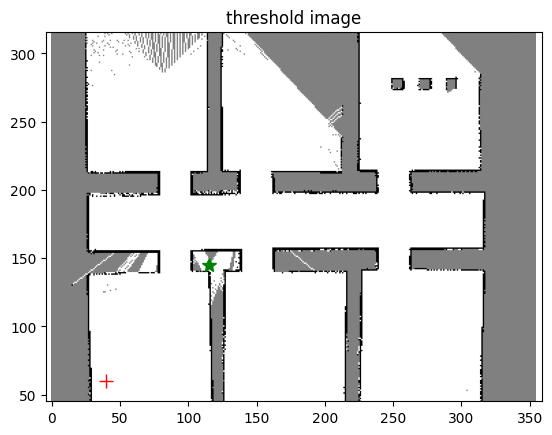

In [9]:
loc_not_reachable = (115, 145)
path_not_reachable = dijkstra(im_thresh, (40, 60), (115, 145))
plot_with_path(im_thresh, zoom=0.75, robot_loc=robot_start_loc, goal_loc=loc_not_reachable, path=path_not_reachable)


In [10]:
grader.check("end_point_not_valid")

end_point_not_valid results:
    end_point_not_valid - 1 result:
        ❌ Test case failed
        Trying:
            path_not_reachable = dijkstra(im_thresh, robot_start_loc, (115, 145))
        Expecting nothing
        **********************************************************************
        Line 1, in end_point_not_valid 0
        Failed example:
            path_not_reachable = dijkstra(im_thresh, robot_start_loc, (115, 145))
        Expected nothing
        Got:
            Goal (115, 145) not reached, taking closest
        Trying:
            assert len(path_not_reachable) > 20
        Expecting nothing
        **********************************************************************
        Line 2, in end_point_not_valid 0
        Failed example:
            assert len(path_not_reachable) > 20
        Exception raised:
            Traceback (most recent call last):
              File "/usr/lib/python3.12/doctest.py", line 1361, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest end_point_not_valid 0[1]>", line 1, in <module>
                assert len(path_not_reachable) > 20
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
            AssertionError

## Hours and collaborators
Required for every assignment - fill out before you hand-in.

Listing names and websites helps you to document who you worked with and what internet help you received in the case of any plagiarism issues. You should list names of anyone (in class or not) who has substantially helped you with an assignment - or anyone you have *helped*. You do not need to list TAs.

Listing hours helps us track if the assignments are too long.

In [11]:

# List of names (create"s a set)
worked_with_names = {"not filled out"}
# List of URLS W26 (creates a set)
websites = {"not filled out"}
# Approximate number of hours, including lab/in-class time
hours = -1.5

In [12]:
grader.check("hours_collaborators")

hours_collaborators results:
    hours_collaborators - 1 result:
        ❌ Test case failed
        Trying:
            assert not 'not filled out' in worked_with_names
        Expecting nothing
        **********************************************************************
        Line 1, in hours_collaborators 0
        Failed example:
            assert not 'not filled out' in worked_with_names
        Exception raised:
            Traceback (most recent call last):
              File "/usr/lib/python3.12/doctest.py", line 1361, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest hours_collaborators 0[0]>", line 1, in <module>
                assert not 'not filled out' in worked_with_names
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
            AssertionError

    hours_collaborators - 2 result:
        ❌ Test case failed
        Trying:
            assert not 'not filled out' in websites
        Expecting nothing
        **********************************************************************
        Line 1, in hours_collaborators 1
        Failed example:
            assert not 'not filled out' in websites
        Exception raised:
            Traceback (most recent call last):
              File "/usr/lib/python3.12/doctest.py", line 1361, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest hours_collaborators 1[0]>", line 1, in <module>
                assert not 'not filled out' in websites
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
            AssertionError

    hours_collaborators - 3 result:
        ❌ Test case failed
        Trying:
            assert hours > 0
        Expecting nothing
        **********************************************************************
        Line 1, in hours_collaborators 2
        Failed example:
            assert hours > 0
        Exception raised:
            Traceback (most recent call last):
              File "/usr/lib/python3.12/doctest.py", line 1361, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest hours_collaborators 2[0]>", line 1, in <module>
                assert hours > 0
                       ^^^^^^^^^
            AssertionError

### To submit

- Do a restart then run all to make sure everything runs ok
- Save the file
- Submit this .ipynb file and path_planning.py through gradescope, Dijkstra
- You do NOT need to submit the data files - we will supply those
- Take out/suppress all print statements
- Make sure your final image with path is visible - this is an entirely manually graded assignment

If the Gradescope autograder fails, please check here first for common reasons for it to fail
    https://docs.google.com/presentation/d/1tYa5oycUiG4YhXUq5vHvPOpWJ4k_xUPp2rUNIL7Q9RI/edit?usp=sharing

Most likely failure for this assignment is not naming the data directory and files correctly; capitalization matters for the Gradescope grader. 

Second most likely failure is because your code ran very, very slowly and the autograder timed out.

Third reason for failure is you forgot to include **path_planning.py** and/or you put the file in a folder